
# LAB 1: ANN and PyTorch


$\color{blue}{\text{Name: Milad Saeedi}}$  

In this lab, you will start off by constructing a neural networks from scratch to get a stronger understanding of what is required to make neural networks work.

Then in the second part of the lab you will train a neural network (using PyTorch) to classify an image into one of two classes: "car" or "truck". The code for the neural networks
you train will be written for you, and you are not (yet!) expected
to understand all provided code. However, by the end of the lab,
you should be able to:

1. Understand at a high level the training loop for a machine learning model.
2. Understand the distinction between training, validation, and test data.
3. The concepts of overfitting and underfitting.
4. Investigate how different hyperparameters, such as learning rate and batch size, affect the success of training.
5. Compare an ANN (aka Multi-Layer Perceptron) with a CNN.

### What to submit

Submit an HTML file containing all your code, outputs, and write-up
from parts A and B. You can produce a HTML file directly from Google Colab. The Colab instructions are provided at the end of this document.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission.

## Colab Link

Include a link to your colab file here

Colab Link: https://drive.google.com/file/d/1mcJHOo1j3mYAY1dqLWRsFo5WymbIniRC/view?usp=sharing

#PART A: Constructing a Neural Network [15 pt]

Before we get into using PyTorch to train our classifier we will go through the process of creating our neural network from scratch. We've seen in the tutorial how to build a 1-layer network, now we'll take it one step further to build a 2-layer network. This is an important exercise that everyone should attempt at least once to understand and truly appreciate the workings of neural networks.

## Part 0. Helper Functions

To help guide the construction we will use the iris dataset that was introduced in the tutorial. Provided are some helper code to get us started:

In [ ]:
# load "Iris_3class.csv" to Google Colab
from google.colab import files
uploaded = files.upload()

Saving Iris_3class.csv to Iris_3class.csv


In [ ]:
import pandas as pd
import numpy as np

raw_data = pd.read_csv("Iris_3class.csv", header = None)
raw_data = raw_data.values
np.random.shuffle(raw_data)

In [ ]:
import numpy as np
#raw_data = raw_data.values

# split your data into training and validation
X_train = raw_data[0:100,:4]
y_train = raw_data[0:100,4:5].astype(int)
X_val = raw_data[100:,:4]
y_val = raw_data[100:,4:5].astype(int)

print(X_train.shape, y_train.shape)
print(X_train.dtype, y_train.dtype)
print(X_val.shape, y_val.shape)
print(X_val.dtype, y_val.dtype)

(100, 4) (100, 1)
float64 int64
(50, 4) (50, 1)
float64 int64


Recall that the neural network output consists of several nodes, one for each output class. Since the labels are provided as integers we will need to convert them into one-hot vectors to match the neural network output format.

In [ ]:
#Convert array to one-hot encoding
def to_one_hot(Y):
    n_col = np.amax(Y) + 1
    binarized = np.zeros((len(Y), n_col))
    for i in range(len(Y)):
        binarized[i, Y[i]] = 1.
    return binarized

In [ ]:
y_train = to_one_hot(y_train)
print(X_train.shape, y_train.shape)
print(X_train.dtype, y_train.dtype)

y_val = to_one_hot(y_val)
print(X_val.shape, y_val.shape)
print(X_val.dtype, y_val.dtype)

(100, 4) (100, 3)
float64 float64
(50, 4) (50, 3)
float64 float64


In [ ]:
#verify one-hot encoding
y_train[0:5,:]

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

## Part 1. Develop a 2-layer ANN [5 pt]
At its core a 2-layer neural network is just a few lines of code. Most of the complexity comes from setting up the training of the network.

Using vectorized form, set up the neural network training to use a cross-entropy loss function and determine the gradients with resepect to the layer 1 and layer 2 weights.

In [ ]:
# write code to create a 2-layer ANN in vectorized form

#define sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-x))

#define softmax
def softmax(x):
  e = np.exp(x)
  return e/e.sum(axis=1, keepdims = True)


def ann(W, X_train, y_train):

  num_hidden = 5
  num_features = 4
  num_outputs = 3

  #Weights
  w0 = W[:20].reshape(num_features, num_hidden)
  w1 = W[20:].reshape(num_hidden, num_outputs)

  #Feed forward
  layer0 = X_train
  layer1 = sigmoid(np.dot(layer0, w0))
  layer2 = np.dot(layer1, w1)

  # softmax
  output = softmax(layer2)

  #Back propagation using gradient descent

  #cross-entropy loss
  error =np.sum(-y_train*np.log(output))# TO BE COMPLETED

  #initialize gradients to zero
  dw0 =np.zeros((4,5)) # TO BE COMPLETED
  dw1 =np.zeros((5,3)) # TO BE COMPLETED

  #calculate gradients
  # TO BE COMPLETED
  dL_dz = output-y_train
  du_dv_hat = w1.T
  dv_hat_dv = layer1*(1-layer1)
  dv_dw0 = X_train
  dz_dw1 = layer1

  #determine gradients
  dw1 +=dz_dw1.T.dot(dL_dz) # TO BE COMPLETED
  dw0 +=dv_dw0.T.dot((dL_dz).dot(du_dv_hat)*(dv_hat_dv)) # TO BE COMPLETED

  #combine gradients into one vector
  dW =np.array(list(dw0.flatten()) + list(dw1.flatten())) # TO BE COMPLETED

  return (error, dW, output)


## Part 2. Train your neural network. How well does your network work on the iris dataset? [5 pt]

In [ ]:
num_hidden = 5
num_features = 4
num_outputs = 3

#initialize weights
w0 = 2*np.random.random((num_features, num_hidden)) - 1
w1 = 2*np.random.random((num_hidden, num_outputs)) - 1

#combine weights into a single vector
W = np.array(list(w0.flatten()) + list(w1.flatten()))

#train network
n = 0.001
iterations = 100000
errors = []
for i in range(iterations):
  (error, dW, y_pred) = ann(W, X_train, y_train)
  W += -dW * n
  errors.append(error)


In [ ]:
#examine predictions on training data
(_, _, y_pred) = ann(W, X_train, y_train)
pred = np.round(y_pred, 0)
pred[:5]

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [ ]:
#examine ground truth training data
train = np.round(y_train, 0)
train[:5]

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])


<font color=blue>In the next line, all rows in training set have been compared :<font>

<font color=blue>Based on the results, we can observe that 100 of the 100 data points in the training set were accurately calculated.<font>

In [ ]:
accuracy=0
for i in range(len(train)):
  if (train[i:i+1]==pred[i:i+1]).all():
    accuracy +=1


print("Number of correct predictions in training set=", accuracy)

Number of correct predictions in training set= 99


<font color=blue>In the following line, the model's performance for the validation data set has been assessed:<font>

<font color=blue>Based on the results, we can observe that 49 of the 50 data points in the validation data set were accurately calculated.<font>

In [ ]:
(_, _, y_pred_val) = ann(W, X_val, y_val)
pred_val = np.round(y_pred_val, 0)

val = np.round(y_val, 0)
N_accuracy=0
for i in range(len(val)):
  if (val[i:i+1]==pred_val[i:i+1]).all():
    N_accuracy +=1


print('Number of correct predictions in validation set=', N_accuracy)

Number of correct predictions in validation set= 50


## Part 3. Validate that the gradients were computed correctly for the 2-layer neural network you developed. [5 pt]
$\color{blue}{\text{answer : }}$  
<font color=blue>The numerical values of gradients are the same as our gradients. As a result, we can conclude that they are correct.<font>

In [ ]:
#write code to numerical verify the gradients you calculated

num_hidden = 5
num_features = 4
num_outputs = 3

#initialize weights
w0 = 2*np.random.random((num_features, num_hidden)) - 1
w1 = 2*np.random.random((num_hidden, num_outputs)) - 1

#combine weights
W =np.array(list(w0.flatten()) + list(w1.flatten())) # TO BE COMPLETED

#compute gradients analytically
(error, dW, y_pred) = ann(W, X_train, y_train)

#compute gradients numerically
dW_num = np.zeros((len(W),1))

for ind in range(len(W)):
  #reset gradients
  We1 = np.array(list(w0.flatten()) + list(w1.flatten()))
  We2 = np.array(list(w0.flatten()) + list(w1.flatten()))

  #increment slightly
  We1[ind] =We1[ind] + 0.000001 # TO BE COMPLETED
  We2[ind] =We2[ind] - 0.000001 # TO BE COMPLETED

  #compute errors
  (error_e1, dW_e1, y_pred1) = ann(We1, X_train, y_train)
  (error_e2, dW_e2, y_pred2) = ann(We2, X_train, y_train)

  #obtain numerical gradients
  grad_num = (error_e1-error_e2)/0.000002# TO BE COMPLETED

  #display difference between numerical and analytic gradients
  print(round(abs(grad_num - dW[ind]), 4), grad_num, dW[ind])


0.0 -1.1831875923462576 -1.1831875989978102
0.0 -0.6646649737263033 -0.6646649789744916
0.0 -0.7012455114363547 -0.701245507839315
0.0 8.477738631995635 8.477738627145484
0.0 28.275180760317653 28.275180751273016
0.0 -0.8169330527607599 -0.8169330502220057
0.0 -0.46126690023129413 -0.4612668984678903
0.0 1.6106418883055085 1.6106418799064504
0.0 3.533773536901208 3.533773539397963
0.0 9.06304059355989 9.06304058604468
0.0 -0.3370803085545049 -0.3370803049839037
0.0 -0.14932553682456273 -0.14932553186379185
0.0 -5.081330492373581 -5.081330498951115
0.0 5.954195451352007 5.954195445331484
0.0 31.499012216329447 31.49901221525722
0.0 -0.04972336142827771 -0.04972336334509923
0.0 0.003990351160609862 0.003990349808181454
0.0 -2.4100079798472507 -2.4100079693798793
0.0 1.4466015443304059 1.4466015460974033
0.0 12.390293733233193 12.390293742559836
0.0 -0.27974915184358906 -0.27974915520508864
0.0 0.1522735786352314 0.15227357928264004
0.0 0.12747557320835767 0.12747557592244882
0.0 -1.14223

# PART B: Cars vs Trucks [35 pt]

In the second part of the lab we will see how we can use PyTorch to train a neural network to identify Cars and Trucks.

In [ ]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms


## Part 0. Helper Functions

We will be making use of the following helper functions. You will be asked to look
at and possibly modify some of these, but you are not expected to understand all of them.

You should look at the function names and read the docstrings. If you are curious, come back and explore the code *after* making some progress on the lab.

In [ ]:
###############################################################################
# Data Loading

def get_relevant_indices(dataset, classes, target_classes):
    """ Return the indices for datapoints in the dataset that belongs to the
    desired target classes, a subset of all possible classes.

    Args:
        dataset: Dataset object
        classes: A list of strings denoting the name of each class
        target_classes: A list of strings denoting the name of desired classes
                        Should be a subset of the 'classes'
    Returns:
        indices: list of indices that have labels corresponding to one of the
                 target classes
    """
    indices = []
    for i in range(len(dataset)):
        # Check if the label is in the target classes
        label_index = dataset[i][1] # ex: 9
        label_class = classes[label_index] # ex: 'truck'
        if label_class in target_classes:
            indices.append(i)
    return indices

def get_data_loader(target_classes, batch_size):
    """ Loads images of cars and trucks, splits the data into training, validation
    and testing datasets. Returns data loaders for the three preprocessed datasets.

    Args:
        target_classes: A list of strings denoting the name of the desired
                        classes. Should be a subset of the argument 'classes'
        batch_size: A int representing the number of samples per batch

    Returns:
        train_loader: iterable training dataset organized according to batch size
        val_loader: iterable validation dataset organized according to batch size
        test_loader: iterable testing dataset organized according to batch size
        classes: A list of strings denoting the name of each class
    """

    classes = ('plane', 'car', 'bird', 'cat',
               'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    ########################################################################
    # The output of torchvision datasets are PILImage images of range [0, 1].
    # We transform them to Tensors of normalized range [-1, 1].
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    # Load CIFAR10 training data
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_indices = get_relevant_indices(trainset, classes, target_classes)

    # Split into train and validation
    np.random.seed(1000) # Fixed numpy random seed for reproducible shuffling
    np.random.shuffle(relevant_indices)
    split = int(len(relevant_indices) * 0.8)  #split at 80%

    # split into training and validation indices
    relevant_train_indices, relevant_val_indices = relevant_indices[:split], relevant_indices[split:]
    train_sampler = SubsetRandomSampler(relevant_train_indices)
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               num_workers=1, sampler=train_sampler)
    val_sampler = SubsetRandomSampler(relevant_val_indices)
    val_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              num_workers=1, sampler=val_sampler)
    # Load CIFAR10 testing data
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_test_indices = get_relevant_indices(testset, classes, target_classes)
    test_sampler = SubsetRandomSampler(relevant_test_indices)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             num_workers=1, sampler=test_sampler)
    return train_loader, val_loader, test_loader, classes

###############################################################################
# Training
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def normalize_label(labels):
    """
    Given a tensor containing 2 possible values, normalize this to 0/1

    Args:
        labels: a 1D tensor containing two possible scalar values
    Returns:
        A tensor normalize to 0/1 value
    """
    max_val = torch.max(labels)
    min_val = torch.min(labels)
    norm_labels = (labels - min_val)/(max_val - min_val)
    return norm_labels

def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        labels = normalize_label(labels)  # Convert labels to 0/1
        outputs = net(inputs)
        loss = criterion(outputs, labels.float())
        corr = (outputs > 0.0).squeeze().long() != labels
        total_err += int(corr.sum())
        total_loss += loss.item()
        total_epoch += len(labels)
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

###############################################################################
# Training Curve
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

## Part 1. Visualizing the Data [5 pt]

We will make use of some of the CIFAR-10 data set, which consists of
colour images of size 32x32 pixels belonging to 10 categories. You can
find out more about the dataset at https://www.cs.toronto.edu/~kriz/cifar.html

For this assignment, we will only be using the car and truck categories.
We have included code that automatically downloads the dataset the
first time that the main script is run.

In [ ]:
# This will download the CIFAR-10 dataset to a folder called "data"
# the first time you run this code.
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["car", "truck"],
    batch_size=1) # One image per batch

  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
train_loader

### Part (a) -- 1 pt

Visualize some of the data by running the code below.
Include the visualization in your writeup.

(You don't need to submit anything else.)  

$\color{blue}{\text{answer  }}$ -<font color=blue> The image of some of data has been added to this markdown: <font>

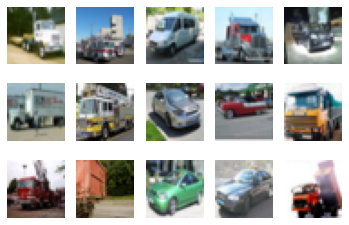

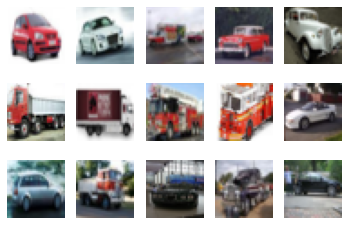

In [ ]:
import matplotlib.pyplot as plt

k = 0
for images, labels in train_loader:
    # since batch_size = 1, there is only 1 image in `images`
    image = images[0]
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    # normalize pixel intensity values to [0, 1]
    img = img / 2 + 0.5
    plt.subplot(3, 5, k+1)
    plt.axis('off')
    plt.imshow(img)

    k += 1
    if k > 14:
        break

### Part (b) -- 2 pt

How many training examples do we have for the combined `car` and `truck` classes?
What about validation examples?
What about test examples?


$\color{blue}{\text{answer : }}$  
- <font color=blue>number of training examples= 8000<font>
- <font color=blue>number of validation examples= 2000<font>
- <font color=blue>number of test examples= 2000<font>

In [ ]:
print('number of training examples=', len(train_loader))
print('number of validation examples=', len(val_loader))
print('number of test examples=', len(test_loader))


number of training examples= 8000
number of validation examples= 2000
number of test examples= 2000


### Part (c) -- 2pt

Why do we need a validation set when training our model? What happens if we judge the
performance of our models using the training set loss/error instead of the validation
set loss/error?

$\color{blue}{\text{Answer: }}$  
- <font color=blue>We change the weights by training the neural
 network with the training data set. To avoid overfitting the network and fine-tune models, we must feed the validation set into the network and check if the error falls within a certain range (This set is not being using directly to adjust the weights but used to give the optimal number of hidden units or determine a stopping point for the back-propagation algorithm)</font>

- <font color=blue> Validation set is different from test set. Validation set actually can be regarded as a part of training set, because it is used to build the model, neural networks or others. Validation set actually can be regarded as a part of training set, because it is used to build the model, neural networks or others. It is usually used for parameter selection and to avoild overfitting. </font>

- <font color=blue>If a non-linear model (such as NN) is only trained on a training set without using validation set to evaluate the model, it is very likely to achieve 100% accuracy and overfit, resulting in poor performance on the test set.</font>

## Part 2. Training [10 pt]

We define two neural networks, a `LargeNet` and `SmallNet`.
We'll be training the networks in this section.

You won't understand fully what these networks are doing until
the next few classes, and that's okay. For this assignment, please
focus on learning how to train networks, and how hyperparameters affect
training.

In [ ]:
class LargeNet(nn.Module):
    def __init__(self):
        super(LargeNet, self).__init__()
        self.name = "large"
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5)
        self.fc1 = nn.Linear(10 * 5 * 5, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [ ]:
class SmallNet(nn.Module):
    def __init__(self):
        super(SmallNet, self).__init__()
        self.name = "small"
        self.conv = nn.Conv2d(3, 5, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(5 * 7 * 7, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = self.pool(x)
        x = x.view(-1, 5 * 7 * 7)
        x = self.fc(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [ ]:
small_net = SmallNet()
large_net = LargeNet()

### Part (a) -- 1pt

The methods `small_net.parameters()` and `large_net.parameters()`
produces an iterator of all the trainable parameters of the network.
These parameters are torch tensors containing many scalar values.

We haven't learned how how the parameters in these high-dimensional
tensors will be used, but we should be able to count the number
of parameters. Measuring the number of parameters in a network is
one way of measuring the "size" of a network.

What is the total number of parameters in `small_net` and in
`large_net`? (Hint: how many numbers are in each tensor?)

$\color{blue}{\text{Answer: }}$  
- <font color=blue>By adding the number of parameters, we can calculate the total number of parameters:</font>

- <font color=blue>total number of parameters in `small_net`= 5\*3\*3\*3+5+245+1=$386$ </font>

- <font color=blue>total number of parameters in `large_net`= 5\*3\*5\*5+5+10\*5\*5\*5+10+32\*250+32+32\*1+1=$9705$
</font>

In [ ]:
print("The size of tensors in small_net:")
for param in small_net.parameters():
    print(param.shape)
print("The size of tensors in large_net:")
for param in large_net.parameters():
    print(param.shape)

The size of tensors in small_net:
torch.Size([5, 3, 3, 3])
torch.Size([5])
torch.Size([1, 245])
torch.Size([1])
The size of tensors in large_net:
torch.Size([5, 3, 5, 5])
torch.Size([5])
torch.Size([10, 5, 5, 5])
torch.Size([10])
torch.Size([32, 250])
torch.Size([32])
torch.Size([1, 32])
torch.Size([1])



$\color{blue}{\text{There is a another way for calculating number of parameters that is easier:}}$  
- <font color=blue>By using `.numel()` number of parameters in each tensor can be calculated.  
Total number of parameters in small_net=  $386$  
Total number of parameters in large_net=  $9705$
</font>


In [ ]:
N_p_small=0
for param in small_net.parameters():
    N_p_small+=param.numel()
print('Total number of parameters in small_net= ', N_p_small)
N_p_large=0
for param in large_net.parameters():
      N_p_large+=param.numel()
print('Total number of parameters in large_net= ', N_p_large)

Total number of parameters in small_net=  386
Total number of parameters in large_net=  9705


### The function train_net

The function `train_net` below takes an untrained neural network (like `small_net` and `large_net`) and
several other parameters. You should be able to understand how this function works.
The figure below shows the high level training loop for a machine learning model:

![alt text](https://github.com/UTNeural/Lab2/blob/master/Diagram.png?raw=true)

In [ ]:
def train_net(net, batch_size=64, learning_rate=0.01, num_epochs=30):
    ########################################################################
    # Train a classifier on cars vs trucks
    target_classes = ["car", "truck"]
    ########################################################################
    # Fixed PyTorch random seed for reproducible result
    torch.manual_seed(1000)
    ########################################################################
    # Obtain the PyTorch data loader objects to load batches of the datasets
    train_loader, val_loader, test_loader, classes = get_data_loader(
            target_classes, batch_size)
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be Binary Cross Entropy (BCE). In this case we
    # will use the BCEWithLogitsLoss which takes unnormalized output from
    # the neural network and scalar label.
    # Optimizer will be SGD with Momentum.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):  # loop over the dataset multiple times
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            labels = normalize_label(labels) # Convert labels to 0/1
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            # Calculate the statistics
            corr = (outputs > 0.0).squeeze().long() != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train err: {}, Train loss: {} |"+
               "Validation err: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

### Part (b) -- 1pt

The parameters to the function `train_net` are hyperparameters of our neural network.
We made these hyperparameters easy to modify so that we can tune them later on.

What are the default values of the parameters `batch_size`, `learning_rate`,
and `num_epochs`?


$\color{blue}{\text{answer : }}$  
- <font color=blue>The default values of the parameters are as following: <font>  
<font color=blue>batch_size=64<font>  
<font color=blue>learning_rate=0.01 <font>  
<font color=blue>num_epochs=30 <font>  

### Part (c) -- 1 pt

What files are written to disk when we call `train_net` with `small_net`, and train for 5 epochs? Provide a list
of all the files written to disk, and what information the files contain.


$\color{blue}{\text{Answer : }}$  

<font color=blue>By looking at the **`train_net`** code we can see that with following code  for each ephoc optimized parameters of the model would be saved to disk:  
`torch.save(net.state_dict(), model_path)`<font>

<font color=blue>It is obvious this line of code save parameters of the model (weights and biases) in an file and the name of the files depends on model's `name, batch_size, learning_rate, and epoch`. For example, for epoch=4 the name of the file would be `model_small_bs64_lr0.01_epoch4`. So, 5 files would be save and the name of them would be as following:<font>   
- <font color=blue>model_small_bs64_lr0.01_epoch0  <font>
- <font color=blue>model_small_bs64_lr0.01_epoch1  <font>
- <font color=blue>model_small_bs64_lr0.01_epoch2  <font>
- <font color=blue>model_small_bs64_lr0.01_epoch3  <font>
- <font color=blue>model_small_bs64_lr0.01_epoch4<font>  
- <font color=blue>model_small_bs64_lr0.01_epoch4_train_err <font>  
- <font color=blue>model_small_bs64_lr0.01_epoch4_train_loss <font>  
- <font color=blue>model_small_bs64_lr0.01_epoch4_val_err <font>  
- <font color=blue>model_small_bs64_lr0.01_epoch4_val_loss <font>  

<font color=blue>Moreover, We can add following code after `torch.save(net.state_dict(), model_path)` to see what would be save in these files:  <font>  


`torch.save(net.state_dict(), model_path)`   
`for param_tensor in net.state_dict():`   
`   ---print(param_tensor, "\t", net.state_dict()[param_tensor].size())`
<font>  

<font color=blue>By doing so, we can see that following parameters would be save in every epoch in every file:   
`conv.weight 	 torch.Size([5, 3, 3, 3])`  
`conv.bias 	 torch.Size([5])`  
`fc.weight 	 torch.Size([1, 245])`   
`fc.bias 	 torch.Size([1]` <font>  



In [ ]:
# Initialize model
#model = SmallNet()
# Initialize optimizer
#optimizer = optim.SGD(model.parameters(), epoch=29)
#small_net=train_net(model, num_epochs=5)
# Print model's state_dict


### Part (d) -- 2pt

Train both `small_net` and `large_net` using the function `train_net` and its default parameters.
The function will write many files to disk, including a model checkpoint (saved values of model weights)
at the end of each epoch.

If you are using Google Colab, you will need to mount Google Drive
so that the files generated by `train_net` gets saved. We will be using
these files in part (d).
(See the Google Colab tutorial for more information about this.)

Report the total time elapsed when training each network. Which network took longer to train?
Why?


$\color{blue}{\text{answer : }}$  

  
<font color=blue>The total time elapsed for `large_net`= $111 s$<font>  
<font color=blue>The total time elapsed for `small_net`= $98 s$<font>

<font color=blue>The `large_net` network took longer to train because it has more layers and more paramerets in training process.<font>

In [ ]:
# Since the function writes files to disk, you will need to mount
# your Google Drive. If you are working on the lab locally, you
# can comment out this code.

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
L_net=train_net(large_net)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.4055, Train loss: 0.66854238986969 |Validation err: 0.357, Validation loss: 0.6399658787995577
Epoch 2: Train err: 0.34325, Train loss: 0.6194908964633942 |Validation err: 0.34, Validation loss: 0.6194428633898497
Epoch 3: Train err: 0.302875, Train loss: 0.5762610063552857 |Validation err: 0.2675, Validation loss: 0.5406947452574968
Epoch 4: Train err: 0.251625, Train loss: 0.5151505508422851 |Validation err: 0.228, Validation loss: 0.4729145197197795
Epoch 5: Train err: 0.20575, Train loss: 0.45367169857025147 |Validation err: 0.18, Validation loss: 0.4133589072152972
Epoch 6: Train err: 0.186875, Train loss: 0.4191136605739593 |Validation err: 0.1745, Validation loss: 0.4069544058293104
Epoch 7: Train err: 0.163125, Train loss: 0.37528541433811186 |Validation err: 0.169, Validation loss: 0.40669534262269735
Epoch 8: Train err: 0.15925, Train loss: 0.36489994168281553 |Validation err: 0.

In [ ]:
S_net=train_net(small_net)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.36375, Train loss: 0.629534749507904 |Validation err: 0.331, Validation loss: 0.6065418841317296
Epoch 2: Train err: 0.294375, Train loss: 0.5720003054141999 |Validation err: 0.29, Validation loss: 0.5699597075581551
Epoch 3: Train err: 0.26375, Train loss: 0.5353880693912506 |Validation err: 0.2515, Validation loss: 0.518416641280055
Epoch 4: Train err: 0.229, Train loss: 0.48501357626914976 |Validation err: 0.215, Validation loss: 0.4671405339613557
Epoch 5: Train err: 0.20875, Train loss: 0.4544841313362122 |Validation err: 0.2165, Validation loss: 0.44888175558298826
Epoch 6: Train err: 0.199125, Train loss: 0.44310452485084534 |Validation err: 0.229, Validation loss: 0.4737075865268707
Epoch 7: Train err: 0.193625, Train loss: 0.42737388706207274 |Validation err: 0.195, Validation loss: 0.43351874593645334
Epoch 8: Train err: 0.179625, Train loss: 0.4134708720445633 |Validation err: 0

### Part (e) - 2pt

Use the function `plot_training_curve` to display the trajectory of the
training/validation error and the training/validation loss.
You will need to use the function `get_model_name` to generate the
argument to the `plot_training_curve` function.

Do this for both the small network and the large network. Include both plots
in your writeup.



$\color{blue}{\text{Answer : }}$  

  
<font color=blue>plots of error and loss for `small_net` and `large_net` have been added:<font>  


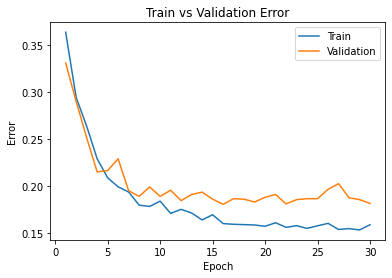

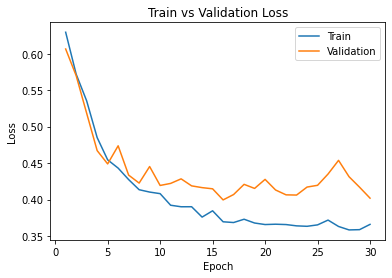

In [ ]:
#model_path = get_model_name("small", batch_size=??, learning_rate=??, epoch=29)
model_path = get_model_name("small", batch_size=64, learning_rate=0.01, epoch=29)

plot_training_curve(model_path)

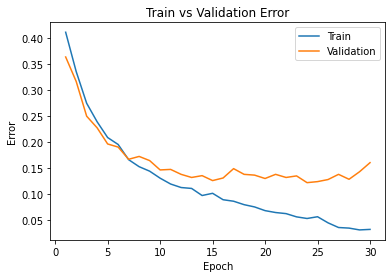

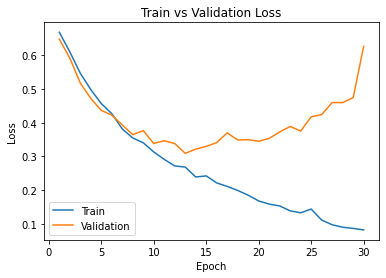

In [ ]:
model_path = get_model_name("large", batch_size=64, learning_rate=0.01, epoch=29)

plot_training_curve(model_path)

### Part (f) - 3pt

Describe what you notice about the training curve.
How do the curves differ for `small_net` and `large_net`?
Identify any occurences of underfitting and overfitting.


$\color{blue}{\text{Answer: }}$  


- <font color=blue>By comparing these curves for `small_net` and `large_net`, we can say that when epoch is bigger that 15 error for `large_net` is smaller than error for `small_net`. So, `large_net` has a better accuracy<font>  
- <font color=blue>For both curves, we can see that when epoch is less than 5, underfitting  has happened<font>  
- <font color=blue> Overfitting has occurred for 'large net' when epoch is more than 20 as the loss has ascended for validation dataset <font>  

<font color=blue>So, the curves for `small_net` and `large_net` are different regarding accuracy and presence of overfitting  <font>  

## Part 3. Optimization Parameters [4 pt]

For this section, we will work with `large_net` only.

### Part (a) - 1pt

Train `large_net` with all default parameters, except set `learning_rate=0.001`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *lowering* the learning rate.



$\color{blue}{\text{Answer: }}$  


- <font color=blue>It takes longer to train the model because by using smaller `learning_rate`, our weights would be updated with smaller step size. <font>  
- <font color=blue>By lowering the learning rate underfitting has happened. **The corves indicate that the model is capable of more learning and possible enhancements, and that the training process was stopped too soon.  The model couldn't learn the training dataset properly.**<font>  


In [ ]:
# Note: When we re-construct the model, we start the training
# with *random weights*. If we omit this code, the values of
# the weights will still be the previously trained values.
large_net = LargeNet()
L_net=train_net(large_net, learning_rate=0.001)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.4585, Train loss: 0.6922090911865234 |Validation err: 0.4145, Validation loss: 0.6918484680354595
Epoch 2: Train err: 0.404, Train loss: 0.6912762837409974 |Validation err: 0.401, Validation loss: 0.6909310147166252
Epoch 3: Train err: 0.39125, Train loss: 0.6897973504066467 |Validation err: 0.3825, Validation loss: 0.6891596242785454
Epoch 4: Train err: 0.391, Train loss: 0.6871493883132934 |Validation err: 0.379, Validation loss: 0.6860428061336279
Epoch 5: Train err: 0.37275, Train loss: 0.6819084930419922 |Validation err: 0.3725, Validation loss: 0.6794121749699116
Epoch 6: Train err: 0.367, Train loss: 0.6722611665725708 |Validation err: 0.3745, Validation loss: 0.6701584309339523
Epoch 7: Train err: 0.367375, Train loss: 0.6595345559120178 |Validation err: 0.3785, Validation loss: 0.6627401951700449
Epoch 8: Train err: 0.36425, Train loss: 0.6492524642944336 |Validation err: 0.3765, 

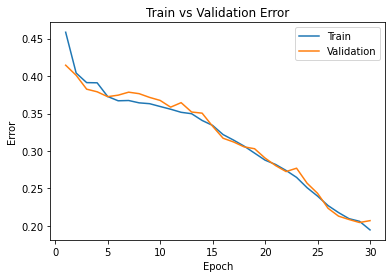

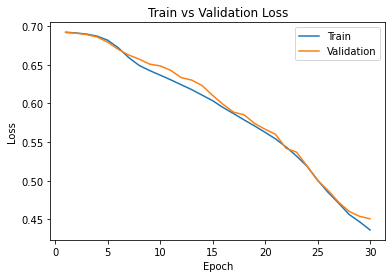

In [ ]:
model_path = get_model_name("large", batch_size=64, learning_rate=0.001, epoch=29)

plot_training_curve(model_path)

### Part (b) - 1pt

Train `large_net` with all default parameters, except set `learning_rate=0.1`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the learning rate.


$\color{blue}{\text{Answer: }}$  


- <font color=blue>It takes shorter to train the model because by increasing `learning_rate`, our weights would be updated with bigger step size. <font>  
- <font color=blue>By increasing the learning rate, at first overfitting happened for smaller epoch number and then underfitting happened for bigger epoch number. **The curves indicate that the model was unable to learn the training dataset at all.**<font>  

In [ ]:
large_net = LargeNet()
L_net=train_net(large_net, learning_rate=0.1)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.3435, Train loss: 0.6152465670108795 |Validation err: 0.2655, Validation loss: 0.5401884317398071
Epoch 2: Train err: 0.26275, Train loss: 0.5457514839172364 |Validation err: 0.2255, Validation loss: 0.47185863088816404
Epoch 3: Train err: 0.205125, Train loss: 0.4577759726047516 |Validation err: 0.196, Validation loss: 0.42472241446375847
Epoch 4: Train err: 0.18375, Train loss: 0.42987853920459745 |Validation err: 0.193, Validation loss: 0.4498207103461027
Epoch 5: Train err: 0.182875, Train loss: 0.4176621789932251 |Validation err: 0.1765, Validation loss: 0.3949774377979338
Epoch 6: Train err: 0.1775, Train loss: 0.407295166015625 |Validation err: 0.218, Validation loss: 0.47349493484944105
Epoch 7: Train err: 0.15425, Train loss: 0.36420914459228515 |Validation err: 0.1665, Validation loss: 0.3992267334833741
Epoch 8: Train err: 0.143125, Train loss: 0.34258134818077085 |Validation er

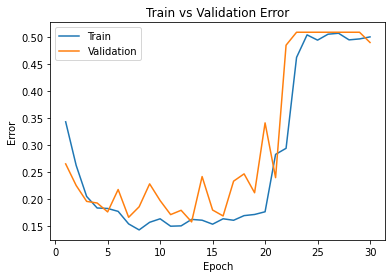

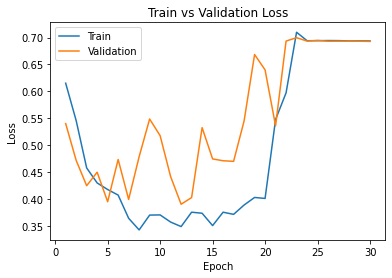

In [ ]:
model_path = get_model_name("large", batch_size=64, learning_rate=0.1, epoch=29)

plot_training_curve(model_path)

### Part (c) - 1pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=512`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the batch size.




$\color{blue}{\text{Answer: }}$  


- <font color=blue>It takes shorter to train the model because by increasing the batch size, as it is equivalent to taking a few big steps, instead of taking many little steps.<font>  
- <font color=blue>By increasing the batch size underfitting has happened. **The corves indicate that the model is capable of more learning and possible enhancements, and that the training process was stopped too soon.  The model couldn't learn the training dataset properly.**<font>  

In [ ]:
large_net = LargeNet()
L_net=train_net(large_net, batch_size=512)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.466, Train loss: 0.6923338621854782 |Validation err: 0.44, Validation loss: 0.6918952614068985
Epoch 2: Train err: 0.413, Train loss: 0.6914851702749729 |Validation err: 0.403, Validation loss: 0.6910877674818039
Epoch 3: Train err: 0.4035, Train loss: 0.6901152096688747 |Validation err: 0.3925, Validation loss: 0.6894860416650772
Epoch 4: Train err: 0.4, Train loss: 0.6876360848546028 |Validation err: 0.393, Validation loss: 0.686403214931488
Epoch 5: Train err: 0.373625, Train loss: 0.6824756488204002 |Validation err: 0.374, Validation loss: 0.6796957552433014
Epoch 6: Train err: 0.364375, Train loss: 0.6726636365056038 |Validation err: 0.3685, Validation loss: 0.6694183051586151
Epoch 7: Train err: 0.36475, Train loss: 0.6583152934908867 |Validation err: 0.3765, Validation loss: 0.659694567322731
Epoch 8: Train err: 0.365, Train loss: 0.6487302668392658 |Validation err: 0.38, Validation

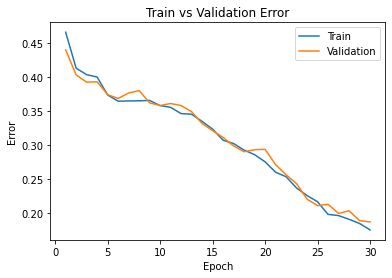

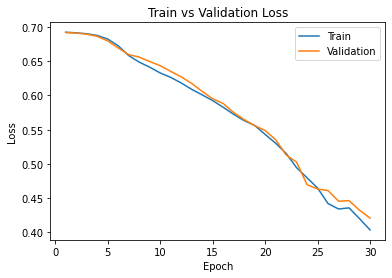

In [ ]:
model_path = get_model_name("large", batch_size=512, learning_rate=0.01, epoch=29)

plot_training_curve(model_path)

### Part (d) - 1pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=16`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *decreasing* the batch size.


$\color{blue}{\text{Answer: }}$  


- <font color=blue>It takes longer to train the model as decreasing the batch size is equivalent to taking many little steps.<font>    
- <font color=blue>By  decreasing the batch size, underfitting happened and the erorr was hight. **The curves indicate that the model was unable to learn the training dataset at all.**<font>  

In [ ]:
large_net = LargeNet()
L_net=train_net(large_net, batch_size=16)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.34375, Train loss: 0.6175165125727653 |Validation err: 0.2625, Validation loss: 0.540454069852829
Epoch 2: Train err: 0.22325, Train loss: 0.4730004854500294 |Validation err: 0.2035, Validation loss: 0.43918069565296175
Epoch 3: Train err: 0.25525, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 4: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 5: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 6: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 7: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 8: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 9: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 10: Train err: 0.502375, Train lo

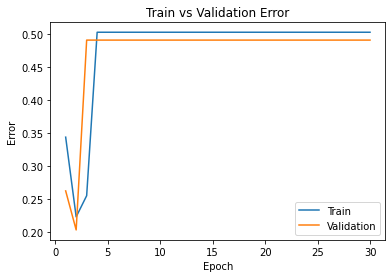

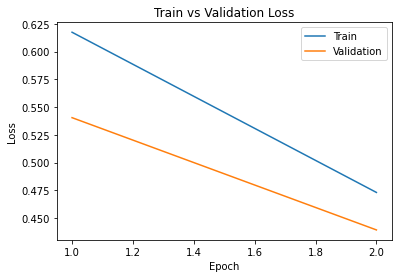

In [ ]:
model_path = get_model_name("large", batch_size=16, learning_rate=0.01, epoch=29)

plot_training_curve(model_path)

## Part 4. Hyperparameter Search [4 pt]



### Part (a) - 1pt

Based on the plots from above, choose another set of values for the hyperparameters (network, batch_size, learning_rate)
that you think would help you improve the validation accuracy. Justify your choice.

$\color{blue}{\text{Answer: }}$  


- <font color=blue>I'm going to choose `large_net` becuase the error for this network is lower than the other one. <font>  
- <font color=blue>`batch_size=256` has been chosen because when batch size was lower than 64, the model couldn't learn at all. Also, batch_size=512 was so high for model to learn properly. <font>  

- <font color=blue>`learning_rate=0.005` has been chosen because when learning_rate was bigger than 0.01, the model couldn't learn at all and learning_rate=0.001 was too small and Underfitting has happened. <font>  

### Part (b) - 1pt

Train the model with the hyperparameters you chose in part(a), and include the training curve.

In [ ]:
large_net = LargeNet()
La_net=train_net(large_net, batch_size=256, learning_rate=0.005)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.460625, Train loss: 0.69226199015975 |Validation err: 0.415, Validation loss: 0.691747397184372
Epoch 2: Train err: 0.399375, Train loss: 0.6911687422543764 |Validation err: 0.3975, Validation loss: 0.6906828954815865
Epoch 3: Train err: 0.393625, Train loss: 0.6893080342561007 |Validation err: 0.383, Validation loss: 0.6883944272994995
Epoch 4: Train err: 0.389875, Train loss: 0.6854819972068071 |Validation err: 0.382, Validation loss: 0.683640293776989
Epoch 5: Train err: 0.36575, Train loss: 0.677736921235919 |Validation err: 0.372, Validation loss: 0.6736309677362442
Epoch 6: Train err: 0.363, Train loss: 0.6635145973414183 |Validation err: 0.377, Validation loss: 0.6628554835915565
Epoch 7: Train err: 0.369125, Train loss: 0.6502769626677036 |Validation err: 0.3785, Validation loss: 0.6555572971701622
Epoch 8: Train err: 0.36325, Train loss: 0.6420583333820105 |Validation err: 0.379, 

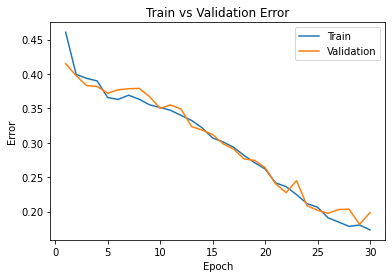

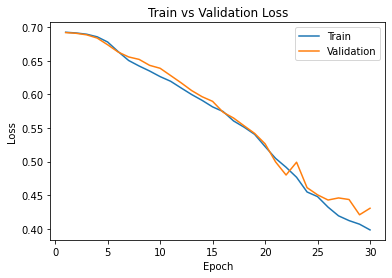

In [ ]:
model_path = get_model_name("large", batch_size=256, learning_rate=0.005, epoch=29)

plot_training_curve(model_path)

### Part (c) - 1pt

Based on your result from Part(a), suggest another set of hyperparameter values to try.
Justify your choice.


$\color{blue}{\text{Answer: }}$  


- <font color=blue>In this part, I'm going to choose `large_net` again becuase the error for this network is lower than the other one. <font>  
- <font color=blue>`batch_size=128` has been chosen because when `batch_size=256`, Underfitting has happened and by decreasing batch_size we may get a better results.<font>  

- <font color=blue>`learning_rate=0.0075` has been chosen because when `learning_rate=0.005`,Underfitting has happened and by increasing learning_rate we may get a better results as bigger steps would be used <font>  

### Part (d) - 1pt

Train the model with the hyperparameters you chose in part(c), and include the training curve.

In [ ]:
large_net = LargeNet()
La_net=train_net(large_net, batch_size=128, learning_rate=0.0075)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.427875, Train loss: 0.6913086242145963 |Validation err: 0.384, Validation loss: 0.6892152279615402
Epoch 2: Train err: 0.376125, Train loss: 0.6793206901777358 |Validation err: 0.372, Validation loss: 0.6674549393355846
Epoch 3: Train err: 0.365375, Train loss: 0.6475536965188526 |Validation err: 0.3705, Validation loss: 0.6461845934391022
Epoch 4: Train err: 0.354, Train loss: 0.6259406190069895 |Validation err: 0.3485, Validation loss: 0.6269116997718811
Epoch 5: Train err: 0.331, Train loss: 0.6033736694426763 |Validation err: 0.3195, Validation loss: 0.5938891693949699
Epoch 6: Train err: 0.296625, Train loss: 0.5725736116606092 |Validation err: 0.296, Validation loss: 0.5605760384351015
Epoch 7: Train err: 0.27125, Train loss: 0.5414408005419231 |Validation err: 0.267, Validation loss: 0.5306929796934128
Epoch 8: Train err: 0.235, Train loss: 0.4922705425156487 |Validation err: 0.2175

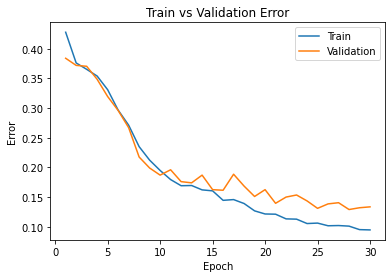

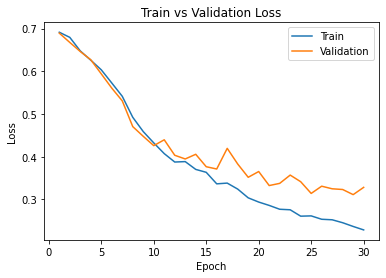

In [ ]:
model_path = get_model_name("large", batch_size=128, learning_rate=0.0075, epoch=29)

plot_training_curve(model_path)

## Part 4. Evaluating the Best Model [9 pt]


### Part (a) - 1pt

Choose the **best** model that you have so far. This means choosing the best model checkpoint,
including the choice of `small_net` vs `large_net`, the `batch_size`, `learning_rate`,
**and the epoch number**.

Modify the code below to load your chosen set of weights to the model object `net`.

In [ ]:
net = LargeNet()
model_path = get_model_name(net.name, batch_size=128, learning_rate=0.0075, epoch=27)
state = torch.load(model_path)
net.load_state_dict(state)


<All keys matched successfully>

### Part (b) - 2pt

Justify your choice of model from part (a).


$\color{blue}{\text{Answer: }}$  


- <font color=blue>By comparing the results for all the networks and all htperparameters, we can see that  `large_net`with
`batch_size=128`,`learning_rate=0.0075`, and `epoch=27`
has the lowest erorr and lowest loss. So, bacause of low erorr and loss for train and validation set, this model has been chosen. <font>  

### Part (c) - 2pt

Using the code in Part 0, any code from lecture notes, or any code that you write,
compute and report the **test classification error** for your chosen model.



$\color{blue}{\text{Answer: }}$  


- <font color=blue> test classification error=0.1415 <font>  


In [ ]:
# If you use the `evaluate` function provided in part 0, you will need to
# set batch_size > 1

train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["car", "truck"],
    batch_size=64)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
criterion = nn.BCEWithLogitsLoss()
print("Error and loss of the model for test set=", evaluate(net, test_loader, criterion))
print("Error and loss of the model for test set=",evaluate(net, val_loader, criterion))

Error and loss of the model for test set= (0.1415, 0.32485127774998546)
Error and loss of the model for test set= (0.129, 0.31973288860172033)


### Part (d) - 2pt

How does the test classification error compare with the **validation error**?
Explain why you would expect the test error to be *higher* than the validation error.



$\color{blue}{\text{Answer: }}$  


<font color=blue> Test clasification error was higher than validation error as we expected. We would expect test error to be higher because we use validation set for parameter tunning. So, our model is biased toward validation set.  <font>  

### Part (e) - 2pt

Why did we only use the test data set at the very end?
Why is it important that we use the test data as little as possible?



$\color{blue}{\text{Answer: }}$  


- <font color=blue>The main reason was that we wanted to have an unbiased stimation of preformance of the model <font color=green>

- <font color=blue>Using the test data as little as possible is important because the step of “choosing the best model” (based on validation performance) can cause a form of overfitting. Think about it this way: let’s say we tried a THOUSAND different models or model variations on our data, and we have validation set performance for all of them. The act of choosing the model with the best validation set performance inherently means that we, the human, have “tuned” the model details for the validation set. The performance value we see for the validation set on “the best model on the validation set” is inherently inflated. To get a non-inflated and more reliable estimate of how well this “best model” will do on data it’s never seen before, we need to use more data it’s never seen before! This is the test set. The test set performance will typically be slightly lower than the validation set performance.<font color=green>


- <font color=blue>
The validation dataset is different from the test dataset that is also held back from the training of the model. So test set  is  used to give an unbiased estimate of the skill of the final tuned model.<font>



- <font color=blue>A validation dataset is a sample of data held back from training your model that is used to give an estimate of model skill while tuning model’s hyperparameters and we use them during tunning.<font color=green>


## Part 5. Fully-Connected Linear ANN vs CNN [3 pt]

Test out a 3-layer linear fully-connected ANN architecture (see simpleANN below). You should explore different hyperparameter settings to determine how well you can do on the validation dataset. Once satisified with the performance, you may test it out on the test data.

How does the your best CNN model compare with an 2-layer linear ANN model (no convolutional layers) on classifying car and truck images?




$\color{blue}{\text{Answer: }}$  


- <font color=blue>
" After exploring different hyperparameter settings we can see that model with
`batch_size=512`, `learning_rate=0.005`, `epoch=29` is the best one. The error of this model on test set is 0.259. <font color=green>

- <font color=blue> Based on error for our test and validation set, our best CNN model was so better than the 2-layer linear ANN model (no convolutional layers) on classifying car and truck images- <font color=blue>

<font color=blue> Error of the model for test set using  ANN model = 0.259 <font color=blue>

<font color=blue> Error of the model for test set using  CNN model = 0.1415 <font color=blue>

In [ ]:
class simpleANN(nn.Module):
    def __init__(self):
        super(simpleANN, self).__init__()
        self.name = "simple"
        self.fc1 = nn.Linear(32*32*3, 100)
        self.fc2 = nn.Linear(100, 20)
        self.fc3 = nn.Linear(20, 1)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

#### Tunning



- <font color=blue> At first, we model simpleANN using the function train_net and its default parameters. <font color=green>


- <font color=blue> As we cal see overfitting has happened <font color=green>

In [ ]:
simple_net = simpleANN()
L_net=train_net(simple_net)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.350125, Train loss: 0.6169105544090271 |Validation err: 0.319, Validation loss: 0.5992573937401175
Epoch 2: Train err: 0.275375, Train loss: 0.5501088445186615 |Validation err: 0.2725, Validation loss: 0.5507201114669442
Epoch 3: Train err: 0.242125, Train loss: 0.5021015326976777 |Validation err: 0.261, Validation loss: 0.5316026927903295
Epoch 4: Train err: 0.223125, Train loss: 0.4708604979515076 |Validation err: 0.272, Validation loss: 0.5328536927700043
Epoch 5: Train err: 0.203375, Train loss: 0.43842331075668334 |Validation err: 0.26, Validation loss: 0.5304488716647029
Epoch 6: Train err: 0.180625, Train loss: 0.4062604172229767 |Validation err: 0.2725, Validation loss: 0.5590313645079732
Epoch 7: Train err: 0.16375, Train loss: 0.3694559094905853 |Validation err: 0.246, Validation loss: 0.5643421839922667
Epoch 8: Train err: 0.13875, Train loss: 0.3301721056699753 |Validation err:

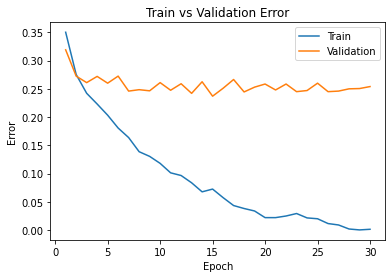

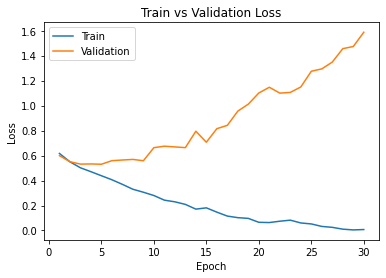

In [ ]:
model_path = get_model_name("simple", batch_size=64, learning_rate=0.01, epoch=29)

plot_training_curve(model_path)




- <font color=blue> We are going to try different hyperparameters <font color=green>


- <font color=blue>In this part, we use `learning_rate=0.001` and other default parameters. <font color=green>



In [ ]:
simple_net = simpleANN()
L_net=train_net(simple_net, learning_rate=0.001)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.4565, Train loss: 0.681265832901001 |Validation err: 0.382, Validation loss: 0.6603339649736881
Epoch 2: Train err: 0.350375, Train loss: 0.6368848595619202 |Validation err: 0.352, Validation loss: 0.6284482646733522
Epoch 3: Train err: 0.327125, Train loss: 0.610190733909607 |Validation err: 0.3295, Validation loss: 0.6098903380334377
Epoch 4: Train err: 0.30925, Train loss: 0.5932393746376038 |Validation err: 0.312, Validation loss: 0.5974772218614817
Epoch 5: Train err: 0.296625, Train loss: 0.5775851504802704 |Validation err: 0.3075, Validation loss: 0.5878970678895712
Epoch 6: Train err: 0.281375, Train loss: 0.5625726225376129 |Validation err: 0.291, Validation loss: 0.576372548006475
Epoch 7: Train err: 0.27, Train loss: 0.5474849174022675 |Validation err: 0.289, Validation loss: 0.5695346472784877
Epoch 8: Train err: 0.260125, Train loss: 0.5336883389949798 |Validation err: 0.2775,

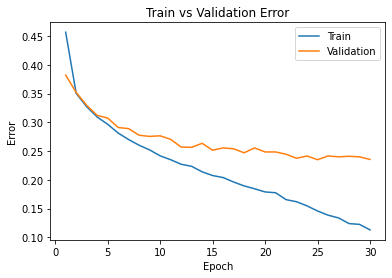

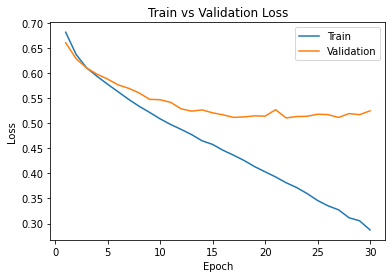

In [ ]:
model_path = get_model_name("simple", batch_size=64, learning_rate=0.001, epoch=29)

plot_training_curve(model_path)


- <font color=blue>In this part, we use ` batch_size=512` and other default parameters<font color=green>


In [ ]:
simple_net = simpleANN()
L_net=train_net(simple_net,  batch_size=512)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.484875, Train loss: 0.6900144666433334 |Validation err: 0.4195, Validation loss: 0.6753106713294983
Epoch 2: Train err: 0.36675, Train loss: 0.6508757993578911 |Validation err: 0.3575, Validation loss: 0.6337455064058304
Epoch 3: Train err: 0.339375, Train loss: 0.6179464161396027 |Validation err: 0.338, Validation loss: 0.6138997226953506
Epoch 4: Train err: 0.322125, Train loss: 0.5996034294366837 |Validation err: 0.32, Validation loss: 0.6033456474542618
Epoch 5: Train err: 0.306875, Train loss: 0.5859731659293175 |Validation err: 0.3075, Validation loss: 0.5925673544406891
Epoch 6: Train err: 0.285375, Train loss: 0.5660174041986465 |Validation err: 0.3005, Validation loss: 0.5806102752685547
Epoch 7: Train err: 0.274, Train loss: 0.5499017760157585 |Validation err: 0.288, Validation loss: 0.5684104710817337
Epoch 8: Train err: 0.26375, Train loss: 0.535404447466135 |Validation err: 0.

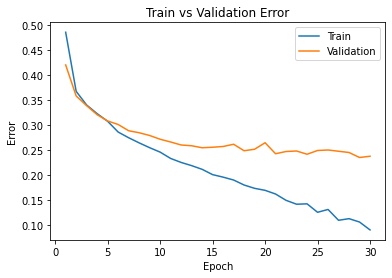

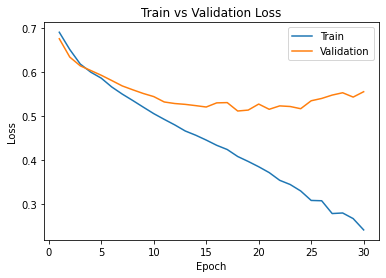

In [ ]:
model_path = get_model_name("simple", batch_size=512, learning_rate=0.01, epoch=29)

plot_training_curve(model_path)

- <font color=blue>In this part, we use ` batch_size=256` and `learning_rate=0.005`<font color=green>

In [ ]:
simple_net = simpleANN()
L_net=train_net(simple_net,  batch_size=256, learning_rate=0.005)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.467875, Train loss: 0.6854314394295216 |Validation err: 0.3755, Validation loss: 0.6647734120488167
Epoch 2: Train err: 0.349625, Train loss: 0.6379391513764858 |Validation err: 0.3475, Validation loss: 0.623713418841362
Epoch 3: Train err: 0.328625, Train loss: 0.6085665300488472 |Validation err: 0.3225, Validation loss: 0.6066028624773026
Epoch 4: Train err: 0.31, Train loss: 0.5885016396641731 |Validation err: 0.3125, Validation loss: 0.5965235233306885
Epoch 5: Train err: 0.29175, Train loss: 0.5770181231200695 |Validation err: 0.2985, Validation loss: 0.5832191929221153
Epoch 6: Train err: 0.275875, Train loss: 0.5542066805064678 |Validation err: 0.294, Validation loss: 0.5700498074293137
Epoch 7: Train err: 0.26325, Train loss: 0.5364840142428875 |Validation err: 0.2825, Validation loss: 0.5583285614848137
Epoch 8: Train err: 0.25275, Train loss: 0.5220399191603065 |Validation err: 0

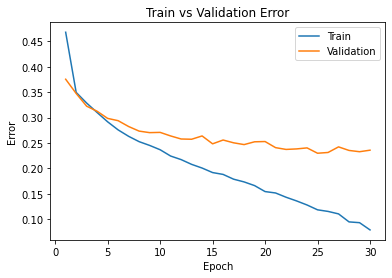

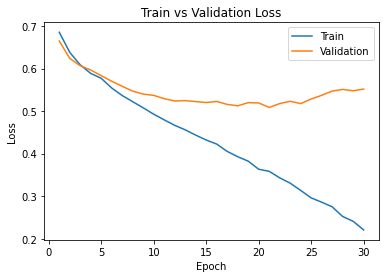

In [ ]:
model_path = get_model_name("simple", batch_size=256, learning_rate=0.005, epoch=29)

plot_training_curve(model_path)

- <font color=blue>In this part, we use `learning_rate=0.1`<font color=green>

In [ ]:
simple_net = simpleANN()
L_net=train_net(simple_net, learning_rate=0.1)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.317, Train loss: 0.5971617703437805 |Validation err: 0.297, Validation loss: 0.590158648788929
Epoch 2: Train err: 0.265375, Train loss: 0.5455267646312714 |Validation err: 0.2755, Validation loss: 0.5865093842148781
Epoch 3: Train err: 0.25275, Train loss: 0.5144806327819824 |Validation err: 0.2835, Validation loss: 0.561789988540113
Epoch 4: Train err: 0.228875, Train loss: 0.4752368903160095 |Validation err: 0.2555, Validation loss: 0.5478774132207036
Epoch 5: Train err: 0.21475, Train loss: 0.4570788652896881 |Validation err: 0.2585, Validation loss: 0.5516372648999095
Epoch 6: Train err: 0.197125, Train loss: 0.41892547512054445 |Validation err: 0.256, Validation loss: 0.6027616458013654
Epoch 7: Train err: 0.18325, Train loss: 0.40008139598369596 |Validation err: 0.253, Validation loss: 0.6593410726636648
Epoch 8: Train err: 0.167, Train loss: 0.3633444799184799 |Validation err: 0.25

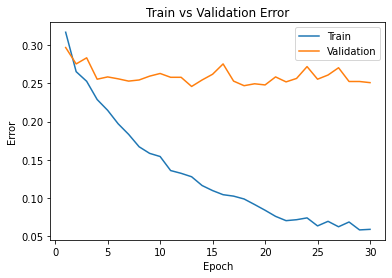

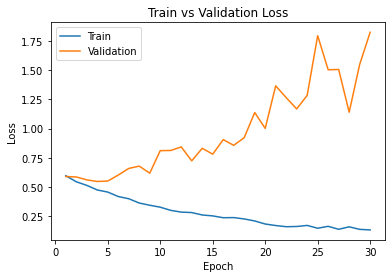

In [ ]:
model_path = get_model_name("simple", batch_size=64, learning_rate=0.1, epoch=29)

plot_training_curve(model_path)

- <font color=blue>In this part, we use ` batch_size=512` and `learning_rate=0.001`<font color=green>

In [ ]:
simple_net = simpleANN()
L_net=train_net(simple_net, batch_size=512, learning_rate=0.001)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.497625, Train loss: 0.7014616169035435 |Validation err: 0.5095, Validation loss: 0.7019032686948776
Epoch 2: Train err: 0.497625, Train loss: 0.6952196471393108 |Validation err: 0.5095, Validation loss: 0.6950041502714157
Epoch 3: Train err: 0.497, Train loss: 0.6888094060122967 |Validation err: 0.507, Validation loss: 0.6894580274820328
Epoch 4: Train err: 0.48625, Train loss: 0.68319221585989 |Validation err: 0.484, Validation loss: 0.6840600073337555
Epoch 5: Train err: 0.455, Train loss: 0.677532009780407 |Validation err: 0.4415, Validation loss: 0.6780042350292206
Epoch 6: Train err: 0.41575, Train loss: 0.6714002452790737 |Validation err: 0.4095, Validation loss: 0.6723612397909164
Epoch 7: Train err: 0.391, Train loss: 0.6654320023953915 |Validation err: 0.3925, Validation loss: 0.6663919687271118
Epoch 8: Train err: 0.375, Train loss: 0.6592176668345928 |Validation err: 0.38, Valid

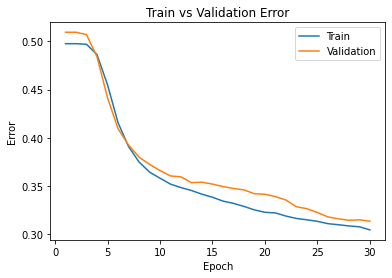

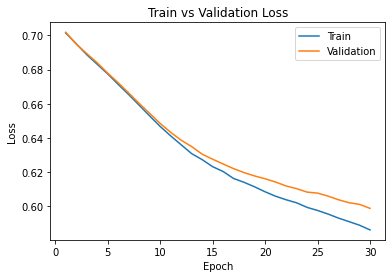

In [ ]:
model_path = get_model_name("simple", batch_size=512, learning_rate=0.001, epoch=29)

plot_training_curve(model_path)

- <font color=blue>In this part, we use ` batch_size=512` and `learning_rate=0.005`<font color=green>

In [ ]:
simple_net = simpleANN()
L_net=train_net(simple_net,  batch_size=512, learning_rate=0.005)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.4975, Train loss: 0.6955180503427982 |Validation err: 0.5045, Validation loss: 0.688106045126915
Epoch 2: Train err: 0.43175, Train loss: 0.6737531945109367 |Validation err: 0.379, Validation loss: 0.664939671754837
Epoch 3: Train err: 0.357875, Train loss: 0.6487355604767799 |Validation err: 0.3575, Validation loss: 0.6399435997009277
Epoch 4: Train err: 0.3445, Train loss: 0.6263367421925068 |Validation err: 0.3465, Validation loss: 0.6241078674793243
Epoch 5: Train err: 0.330625, Train loss: 0.6133294925093651 |Validation err: 0.3375, Validation loss: 0.6139180064201355
Epoch 6: Train err: 0.322375, Train loss: 0.6020837388932705 |Validation err: 0.321, Validation loss: 0.6075703799724579
Epoch 7: Train err: 0.313625, Train loss: 0.592949204146862 |Validation err: 0.312, Validation loss: 0.6005486845970154
Epoch 8: Train err: 0.30275, Train loss: 0.5835652835667133 |Validation err: 0.30

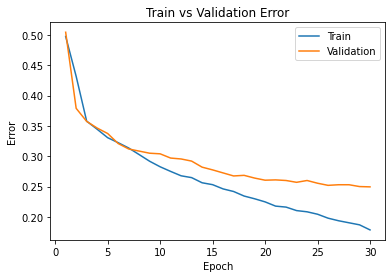

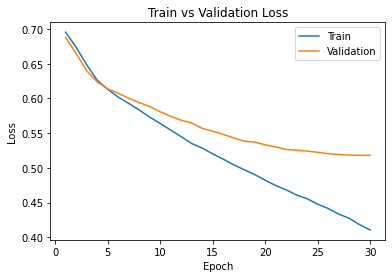

In [ ]:
model_path = get_model_name("simple", batch_size=512, learning_rate=0.005, epoch=29)

plot_training_curve(model_path)

#### Evaluating the Best Model

In [ ]:
net = simpleANN()
model_path = get_model_name(net.name, batch_size=512, learning_rate=0.005, epoch=29)
state = torch.load(model_path)
net.load_state_dict(state)

<All keys matched successfully>

In [ ]:
# If you use the `evaluate` function provided in part 0, you will need to
# set batch_size > 1

train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["car", "truck"],
    batch_size=64)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
criterion = nn.BCEWithLogitsLoss()
print("Error and loss of the model for test set=", evaluate(net, test_loader, criterion))
print("Error and loss of the model for test set=",evaluate(net, val_loader, criterion))

Error and loss of the model for test set= (0.259, 0.5109546575695276)
Error and loss of the model for test set= (0.2495, 0.5159856118261814)


# Saving to HTML
Detailed instructions for saving to HTML can be found <a href="https://stackoverflow.com/questions/53460051/convert-ipynb-notebook-to-html-in-google-colab/64487858#64487858">here</a>. Provided below are a summary of the instructions:

(1) download your ipynb file by clicking on File->Download.ipynb

(2) reupload your file to the temporary Google Colab storage (you can access the temporary storage from the tab to the left)

(3) run the following:

In [ ]:
%%shell
jupyter nbconvert --to html LAB_1_ANN_and_PyTorch.ipynb

[NbConvertApp] Converting notebook LAB_1_ANN_and_PyTorch.ipynb to html
[NbConvertApp] Writing 1407058 bytes to LAB_1_ANN_and_PyTorch.html


(4) the html file will be available for download in the temporary Google Colab storage

(5) review the html file and make sure all the results are visible before submitting your assignment to Quercus